## 1. Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

## 2. Load Feature-Engineered Dataset

In [2]:
feature_path = r"C:\Users\admin\Downloads\feature_engineered_health_dataset.csv"

df = pd.read_csv(feature_path)

print("Shape:", df.shape)
df.head()

Shape: (5200, 71)


,Person_ID,Age,Gender,Education_Level,Income_Level,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Body_Fat_Percentage,...,Existing_Conditions_Hypertension,Existing_Conditions_No Known Condition,Existing_Conditions_Obesity,Existing_Conditions_PCOS,Existing_Conditions_Pre-Diabetes,Medication_Use_Inhaler,Medication_Use_Metformin,Medication_Use_Supplements,Urban_Rural_Suburban,Urban_Rural_Urban
0,P00001,19,0,0,0,162.2,61.8,23.5,65.9,33.9,...,False,False,False,False,False,True,False,False,True,False
1,P00002,16,1,1,2,181.4,56.6,17.2,55.0,13.1,...,False,True,False,False,False,False,False,False,False,True
2,P00003,17,1,1,0,170.2,69.5,24.0,56.2,21.6,...,False,False,False,False,True,False,False,False,True,False
3,P00004,19,1,0,2,169.8,87.4,30.3,71.0,27.7,...,False,True,False,False,False,False,False,False,True,False
4,P00005,15,1,1,1,177.8,77.1,24.4,57.4,18.1,...,False,True,False,False,False,False,False,False,False,False


## 3. Correlation with Target

In [3]:
corr = df.corr(numeric_only=True)

corr_target = corr['Health_Risk_Category'].sort_values(ascending=False)

pd.set_option('display.max_rows', None)
print(corr_target)

Health_Risk_Category                      1.000000
10_Year_Diabetes_Risk_Percent             0.710244
10_Year_Obesity_Risk_Percent              0.688968
10_Year_CVD_Risk_Percent                  0.658685
Fasting_Glucose_mg_dL                     0.635698
BMI                                       0.596858
HbA1c_Percent                             0.594059
Triglycerides_mg_dL                       0.561734
BMI_Category                              0.549235
Waist_Circumference_cm                    0.529647
Weight_kg                                 0.524486
Systolic_BP                               0.520319
LDL_mg_dL                                 0.497202
Cholesterol_Total_mg_dL                   0.445727
Diastolic_BP                              0.439419
Daily_Calorie_Intake                      0.423066
BP_Category                               0.414292
Daily_Sugar_g                             0.400817
Body_Fat_Percentage                       0.400625
Protein_g                      

## 4. Define Features and Target

In [4]:
X = df.drop([
    'Person_ID',
    'Health_Risk_Category',
    '10_Year_Obesity_Risk_Percent',
    '10_Year_Diabetes_Risk_Percent',
    '10_Year_CVD_Risk_Percent'
], axis=1)

y = df['Health_Risk_Category']

print("Features:", X.shape)
print("Target:", y.shape)
print(X.columns)

Features: (5200, 66)
Target: (5200,)
Index(['Age', 'Gender', 'Education_Level', 'Income_Level', 'Height_cm',
       'Weight_kg', 'BMI', 'Waist_Circumference_cm', 'Body_Fat_Percentage',
       'Junk_Food_Frequency_Per_Week', 'Fast_Food_Meals_Per_Week',
       'Sugary_Drinks_Per_Week', 'Processed_Food_Intake',
       'Snack_Frequency_Per_Day', 'Daily_Calorie_Intake',
       'Fruit_Servings_Per_Day', 'Vegetable_Servings_Per_Day',
       'Whole_Grain_Intake', 'Water_Intake_Liters', 'Healthy_Food_Score',
       'Daily_Sugar_g', 'Daily_Sodium_mg', 'Fiber_g', 'Saturated_Fat_g',
       'Protein_g', 'Physical_Activity_Minutes_Per_Day',
       'Exercise_Frequency_Per_Week', 'Sleep_Hours', 'Stress_Level',
       'Alcohol_Consumption', 'Family_History_Diabetes',
       'Family_History_Heart_Disease', 'Fasting_Glucose_mg_dL',
       'HbA1c_Percent', 'Cholesterol_Total_mg_dL', 'HDL_mg_dL', 'LDL_mg_dL',
       'Triglycerides_mg_dL', 'Food_Accessibility_Score',
       'Screen_Time_Hours_Per_Day', 'Sys

## 5. Stratified Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

Train: (4160, 66)
Test: (1040, 66)
Health_Risk_Category
1    2742
0    1127
2     291
Name: count, dtype: int64
Health_Risk_Category
1    686
0    282
2     72
Name: count, dtype: int64


## 6. Data Type and Missing-Value Check

In [6]:
X_train = X_train.apply(pd.to_numeric)

print("X missing:")
print(X.isna().sum().sum())

print("y missing:")
print(y.isna().sum())

print("X_train missing:")
print(X_train.isna().sum().sum())

print("y_train missing:")
print(y_train.isna().sum())

print(X_train.dtypes.value_counts())

X missing:
0
y missing:
0
X_train missing:
0
y_train missing:
0
int64      24
bool       22
float64    20
Name: count, dtype: int64


## 7. Check Train-Test Overlap

In [7]:
train_ids = set(X_train.index)
test_ids = set(X_test.index)

print("Train-test index overlap:", len(train_ids.intersection(test_ids)))

Train-test index overlap: 0


## 8. Handle Class Imbalance with SMOTE

In [8]:
# Install once if imbalanced-learn is not already installed:
# !pip install imbalanced-learn

from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42,
    sampling_strategy='not majority'
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Original X_train:", X_train.shape)
print("SMOTE X_train:", X_train_smote.shape)
print("Original class distribution:")
print(y_train.value_counts())
print("SMOTE class distribution:")
print(y_train_smote.value_counts())

Original X_train: (4160, 66)
SMOTE X_train: (8226, 66)
Original class distribution:
Health_Risk_Category
1    2742
0    1127
2     291
Name: count, dtype: int64
SMOTE class distribution:
Health_Risk_Category
1    2742
0    2742
2    2742
Name: count, dtype: int64


In [9]:
print("SMOTE missing values:", X_train_smote.isna().sum().sum())

SMOTE missing values: 0


## 9. Feature Scaling — Logistic Regression

In [10]:
scaler = StandardScaler()

X_train_scaled_smote = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = scaler.transform(X_train)

## 10. Model 1 — Logistic Regression

In [11]:
lr = LogisticRegression()
lr.fit(X_train_scaled_smote, y_train_smote)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [12]:
y_pred_lr = lr.predict(X_test_scaled)
y_pred_lr_tr = lr.predict(X_train_scaled)

              precision    recall  f1-score   support

         Low       0.84      0.85      0.85       282
    Moderate       0.92      0.90      0.91       686
        High       0.74      0.86      0.79        72

    accuracy                           0.89      1040
   macro avg       0.83      0.87      0.85      1040
weighted avg       0.89      0.89      0.89      1040



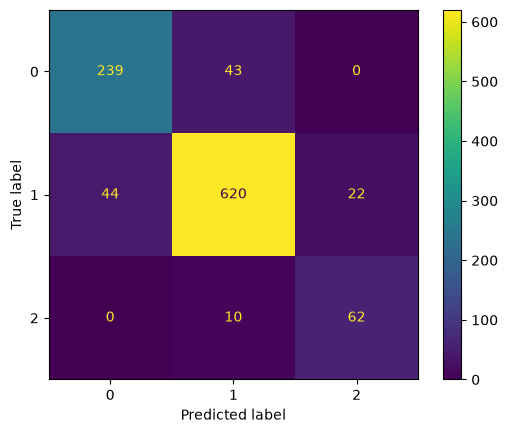

Test accuracy: 0.885576923076923
Test macro F1: 0.8511083694697361


In [13]:
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=['Low', 'Moderate', 'High']
))

accuracy_lr = accuracy_score(y_test, y_pred_lr)
accuracy_lr_tr = accuracy_score(y_train, y_pred_lr_tr)

precision_lr = precision_score(y_test, y_pred_lr, average='macro')
recall_lr = recall_score(y_test, y_pred_lr, average='macro')
recall_lr_tr = recall_score(y_train, y_pred_lr_tr, average='macro')

f1_lr = f1_score(y_test, y_pred_lr, average='macro')
f1_lr_tr = f1_score(y_train, y_pred_lr_tr, average='macro')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_lr)).plot()
plt.show()

print("Test accuracy:", accuracy_lr)
print("Test macro F1:", f1_lr)

In [14]:
high_risk_index = y_test == 2

print("Actual High Risk Cases:", high_risk_index.sum())
print(
    "Correctly Predicted High Risk:",
    ((y_test == 2) & (y_pred_lr == 2)).sum()
)

Actual High Risk Cases: 72
Correctly Predicted High Risk: 62


## 11. Model 2 — Random Forest

In [15]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5
)

rf.fit(X_train_smote, y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstra

In [16]:
y_pred_rf = rf.predict(X_test)
y_pred_rf_tr = rf.predict(X_train)

              precision    recall  f1-score   support

         Low       0.78      0.85      0.81       282
    Moderate       0.91      0.83      0.87       686
        High       0.55      0.86      0.67        72

    accuracy                           0.83      1040
   macro avg       0.75      0.84      0.78      1040
weighted avg       0.85      0.83      0.84      1040



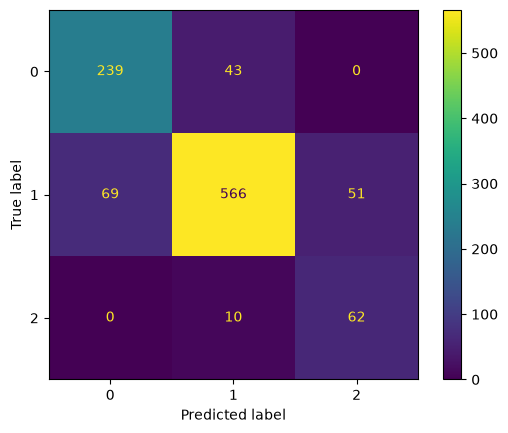

Test accuracy: 0.8336538461538462
Test macro F1: 0.7826242373290883


In [17]:
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=['Low', 'Moderate', 'High']
))

accuracy_rf = accuracy_score(y_test, y_pred_rf)
accuracy_rf_tr = accuracy_score(y_train, y_pred_rf_tr)

precision_rf = precision_score(y_test, y_pred_rf, average='macro')
recall_rf = recall_score(y_test, y_pred_rf, average='macro')
recall_rf_tr = recall_score(y_train, y_pred_rf_tr, average='macro')

f1_rf = f1_score(y_test, y_pred_rf, average='macro')
f1_rf_tr = f1_score(y_train, y_pred_rf_tr, average='macro')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf)).plot()
plt.show()

print("Test accuracy:", accuracy_rf)
print("Test macro F1:", f1_rf)

### Random Forest Hyperparameter Tuning

In [18]:
param_grid = {
    'n_estimators': [150, 200, 250],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [2, 3, 4]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid.fit(X_train_smote, y_train_smote)

print("Best parameters:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

Best parameters: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 250}
Best CV F1: 0.9336668667200472


In [19]:
best_rf = grid.best_estimator_
best_rf.fit(X_train_smote, y_train_smote)

y_pred_best = best_rf.predict(X_test)

print(classification_report(
    y_test,
    y_pred_best,
    target_names=['Low', 'Moderate', 'High']
))

accuracy_rf_best = accuracy_score(y_test, y_pred_best)
precision_rf_best = precision_score(y_test, y_pred_best, average='macro')
recall_rf_best = recall_score(y_test, y_pred_best, average='macro')
f1_rf_best = f1_score(y_test, y_pred_best, average='macro')

              precision    recall  f1-score   support

         Low       0.80      0.84      0.82       282
    Moderate       0.91      0.86      0.89       686
        High       0.62      0.81      0.70        72

    accuracy                           0.85      1040
   macro avg       0.78      0.84      0.80      1040
weighted avg       0.86      0.85      0.86      1040



In [20]:
high_risk_index = y_test == 2

print("Actual High Risk Cases:", high_risk_index.sum())
print(
    "Correctly Predicted High Risk:",
    ((y_test == 2) & (y_pred_rf == 2)).sum()
)
print(
    "Correctly Predicted High Risk after tuning:",
    ((y_test == 2) & (y_pred_best == 2)).sum()
)

Actual High Risk Cases: 72
Correctly Predicted High Risk: 62
Correctly Predicted High Risk after tuning: 58


## 12. Model 3 — XGBoost

In [21]:
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train_smote, y_train_smote)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

              precision    recall  f1-score   support

         Low       0.83      0.85      0.84       282
    Moderate       0.92      0.88      0.90       686
        High       0.66      0.85      0.74        72

    accuracy                           0.87      1040
   macro avg       0.80      0.86      0.83      1040
weighted avg       0.88      0.87      0.87      1040



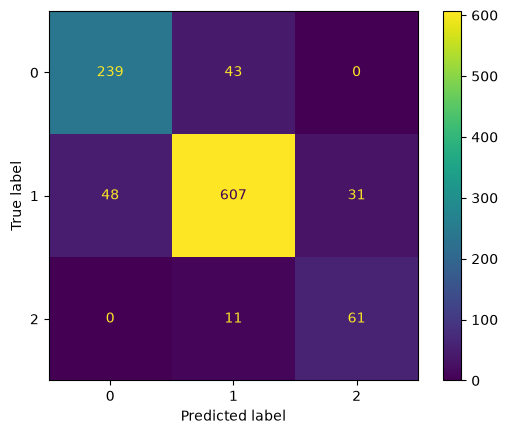

Test accuracy: 0.8721153846153846
Test macro F1: 0.8284116005465817


In [22]:
y_pred_xgb = xgb.predict(X_test)
y_pred_xgb_tr = xgb.predict(X_train)

print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=['Low', 'Moderate', 'High']
))

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
accuracy_xgb_tr = accuracy_score(y_train, y_pred_xgb_tr)

precision_xgb = precision_score(y_test, y_pred_xgb, average='macro')
recall_xgb = recall_score(y_test, y_pred_xgb, average='macro')
recall_xgb_tr = recall_score(y_train, y_pred_xgb_tr, average='macro')

f1_xgb = f1_score(y_test, y_pred_xgb, average='macro')
f1_xgb_tr = f1_score(y_train, y_pred_xgb_tr, average='macro')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb)).plot()
plt.show()

print("Test accuracy:", accuracy_xgb)
print("Test macro F1:", f1_xgb)

## 13. Cross Validation

In [23]:
cv_scores = cross_val_score(
    lr,
    X_train,
    y_train,
    cv=5,
    scoring='f1_macro'
)

print("Logistic Regression CV Scores:", cv_scores)
print("Mean F1:", cv_scores.mean())

Logistic Regression CV Scores: [0.70008108 0.76633126 0.71735702 0.70079013 0.72274469]
Mean F1: 0.7214608375444168


In [24]:
cv_scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=5,
    scoring='f1_macro'
)

print("XGBoost CV Scores:", cv_scores)
print("Mean F1:", cv_scores.mean())

XGBoost CV Scores: [0.82451477 0.82988386 0.84765319 0.82361518 0.82075149]
Mean F1: 0.8292836984674805


In [25]:
high_risk_index = y_test == 2

print("Actual High Risk Cases:", high_risk_index.sum())
print(
    "Correctly Predicted High Risk:",
    ((y_test == 2) & (y_pred_xgb == 2)).sum()
)

Actual High Risk Cases: 72
Correctly Predicted High Risk: 61


## 14. Model Comparison

In [26]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_lr, accuracy_rf_best, accuracy_xgb],
    'Precision': [precision_lr, precision_rf_best, precision_xgb],
    'Recall': [recall_lr, recall_rf_best, recall_xgb],
    'F1 Score': [f1_lr, f1_rf_best, f1_xgb]
})

results.sort_values(by='F1 Score', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.885577,0.834622,0.870806,0.851108
2,XGBoost,0.872115,0.804701,0.859860,0.828412
1,Random Forest,0.854808,0.779539,0.837986,0.804540


In [27]:
print("LOGISTIC REGRESSION")
print(classification_report(
    y_test, y_pred_lr,
    target_names=['Low', 'Moderate', 'High']
))

print("BEST RANDOM FOREST")
print(classification_report(
    y_test, y_pred_best,
    target_names=['Low', 'Moderate', 'High']
))

print("XGBOOST")
print(classification_report(
    y_test, y_pred_xgb,
    target_names=['Low', 'Moderate', 'High']
))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

         Low       0.84      0.85      0.85       282
    Moderate       0.92      0.90      0.91       686
        High       0.74      0.86      0.79        72

    accuracy                           0.89      1040
   macro avg       0.83      0.87      0.85      1040
weighted avg       0.89      0.89      0.89      1040

BEST RANDOM FOREST
              precision    recall  f1-score   support

         Low       0.80      0.84      0.82       282
    Moderate       0.91      0.86      0.89       686
        High       0.62      0.81      0.70        72

    accuracy                           0.85      1040
   macro avg       0.78      0.84      0.80      1040
weighted avg       0.86      0.85      0.86      1040

XGBOOST
              precision    recall  f1-score   support

         Low       0.83      0.85      0.84       282
    Moderate       0.92      0.88      0.90       686
        High       0.66     

## 15. Export Model Results

In [28]:
results_path = r"C:\Users\admin\Downloads\Model_comparison.csv"
results.to_csv(results_path, index=False)

cm_df = pd.DataFrame(
    confusion_matrix(y_test, y_pred_lr),
    index=['Low', 'Moderate', 'High'],
    columns=['Low', 'Moderate', 'High']
)

cm_path = r"C:\Users\admin\Downloads\confusion_matrix.csv"
cm_df.to_csv(cm_path)

pred_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_lr
})

pred_path = r"C:\Users\admin\Downloads\predictions.csv"
pred_df.to_csv(pred_path, index=False)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': abs(lr.coef_).mean(axis=0)
})

importance.sort_values(
    by='Coefficient',
    ascending=False,
    inplace=True
)

importance_path = r"C:\Users\admin\Downloads\feature_importance.csv"
importance.to_csv(importance_path, index=False)

print("Exported:")
print(results_path)
print(cm_path)
print(pred_path)
print(importance_path)

Exported:
C:\Users\admin\Downloads\Model_comparison.csv
C:\Users\admin\Downloads\confusion_matrix.csv
C:\Users\admin\Downloads\predictions.csv
C:\Users\admin\Downloads\feature_importance.csv
